In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
import cv2

In [ ]:
uploaded = files.upload()
img = cv2.imread(uploaded)

In [ ]:
def imag_extract(img):
  # Convertir a RGB
  img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

  # Escala de grises
  IEG = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

  # Umbralizacion
  u_img,th1_img = cv2.threshold(IEG,100,255,cv2.THRESH_BINARY)






In [ ]:
uploaded = files.upload()

mnist = pd.read_csv("data_mnist_.csv")

Saving data_mnist_.csv to data_mnist_.csv


In [ ]:
# Una vez sin valores nulos, filtramos los datos de las clases 2 y 7 escogidas
mnist_filtrado = mnist[mnist["Clase"].isin([2,7])]

In [ ]:
print(mnist_filtrado["Clase"].value_counts(normalize=True))  # Porcentaje por clase para ver si está desbalanceado
print(mnist_filtrado["Clase"].value_counts())

Clase
7.0    0.512558
2.0    0.487442
Name: proportion, dtype: float64
Clase
7.0    6265
2.0    5958
Name: count, dtype: int64


In [ ]:
mnist_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12223 entries, 12665 to 48199
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Clase         12223 non-null  float64
 1   Muestra       12223 non-null  float64
 2   prom_ai       12223 non-null  float64
 3   desv_est_ai   12223 non-null  float64
 4   cur_ai        12171 non-null  float64
 5   asime_ai      12171 non-null  float64
 6   prom_ad       12223 non-null  float64
 7   desv_est_ad   12223 non-null  float64
 8   cur_ad        12217 non-null  float64
 9   asime_ad      12217 non-null  float64
 10  prom_abi      12223 non-null  float64
 11  desv_est_abi  12223 non-null  float64
 12  cur_abi       11800 non-null  float64
 13  asime_abi     11800 non-null  float64
 14  prom_abd      12223 non-null  float64
 15  desv_est_abd  12223 non-null  float64
 16  cur_abd       12223 non-null  float64
 17  asime_abd     12223 non-null  float64
dtypes: float64(18)
memory usage

In [ ]:
mnist_filtrado.describe()

,Clase,Muestra,prom_ai,desv_est_ai,cur_ai,asime_ai,prom_ad,desv_est_ad,cur_ad,asime_ad,prom_abi,desv_est_abi,cur_abi,asime_abi,prom_abd,desv_est_abd,cur_abd,asime_abd
count,12223.000000,12223.000000,12223.000000,12223.000000,12171.000000,12171.000000,12223.000000,12223.000000,12217.000000,12217.000000,12223.000000,12223.000000,11800.000000,11800.000000,12223.000000,12223.000000,12223.000000,12223.000000
mean,4.562791,3058.177698,24.919850,65.728540,9.933059,3.039865,38.012481,81.302168,2.955089,2.051368,33.055277,71.541500,8.989582,2.670149,37.957581,80.614503,3.266850,2.098491
std,2.499314,1767.645037,11.771488,17.294847,16.232179,1.428101,12.554426,12.797165,4.740738,0.661607,19.432561,26.117274,20.228513,1.809875,14.321567,14.259018,4.032948,0.735449
min,2.000000,1.000000,0.000000,0.000000,-1.412345,0.716228,0.000000,0.000000,-1.589256,0.578800,0.000000,0.000000,-1.721751,0.474644,2.234694,19.896826,-1.881679,0.285367
25%,2.000000,1528.500000,16.681122,56.068346,3.156317,2.204195,29.142857,73.287221,0.860866,1.630249,18.660714,59.575276,0.684985,1.574479,27.288265,70.944864,0.724334,1.586397
50%,7.000000,3056.000000,24.198980,67.407646,5.731911,2.701569,36.882653,81.937476,2.179343,1.978558,32.132653,76.696027,2.951985,2.156377,37.234694,81.762581,2.130799,1.961991
75%,7.000000,4584.000000,32.224490,77.549584,10.398465,3.421975,45.908163,90.314807,3.960402,2.365571,46.857143,90.476575,7.752410,3.040127,47.247449,90.885408,4.551035,2.479163
max,7.000000,6265.000000,82.974490,113.322973,191.005128,13.892629,90.974490,114.963391,191.005128,13.892629,97.193878,119.258487,191.005128,13.892629,108.158163,121.678400,90.974222,9.502807


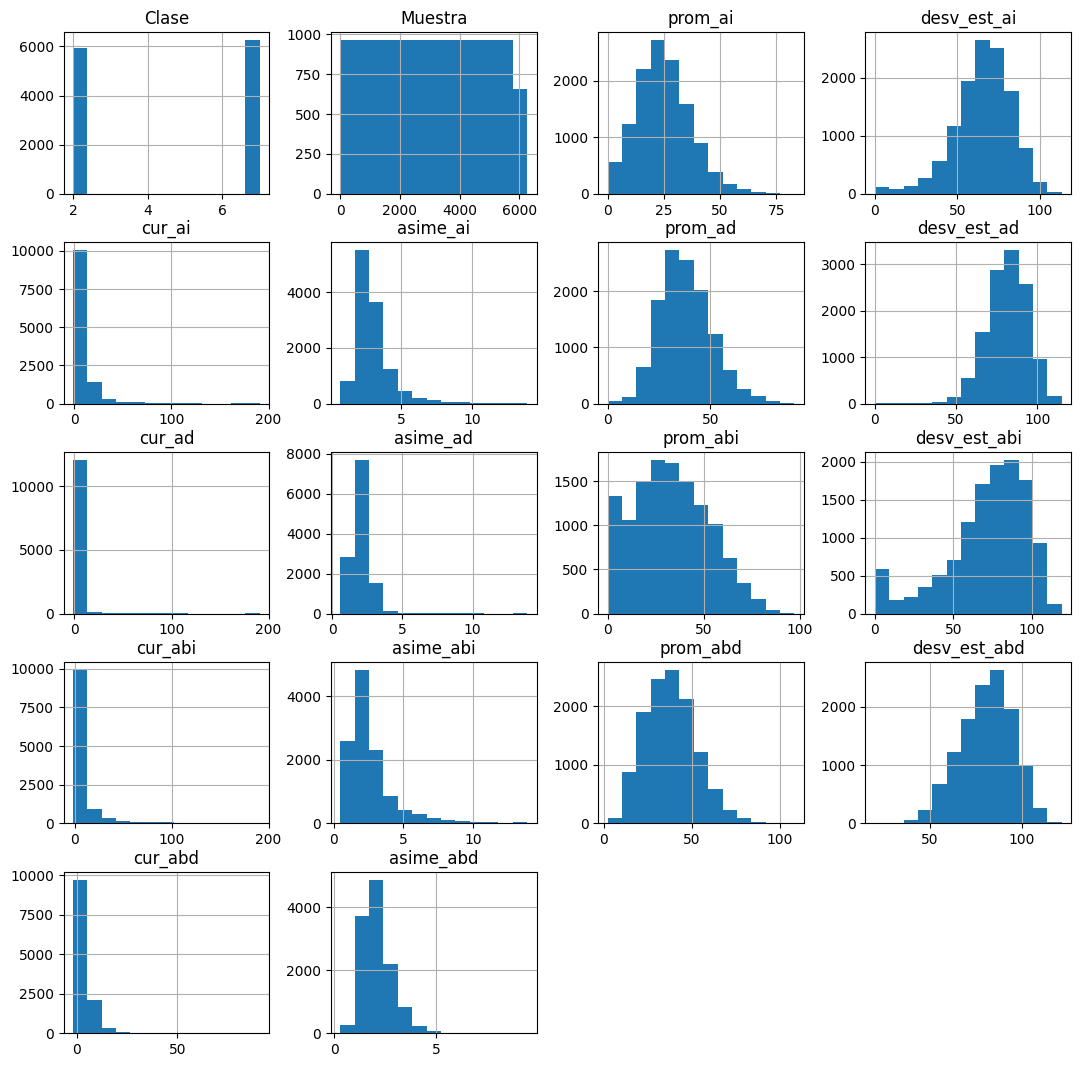

In [ ]:
# Histograma de cada característica
mnist_filtrado.hist(figsize = (13,13),bins=13)
plt.show()

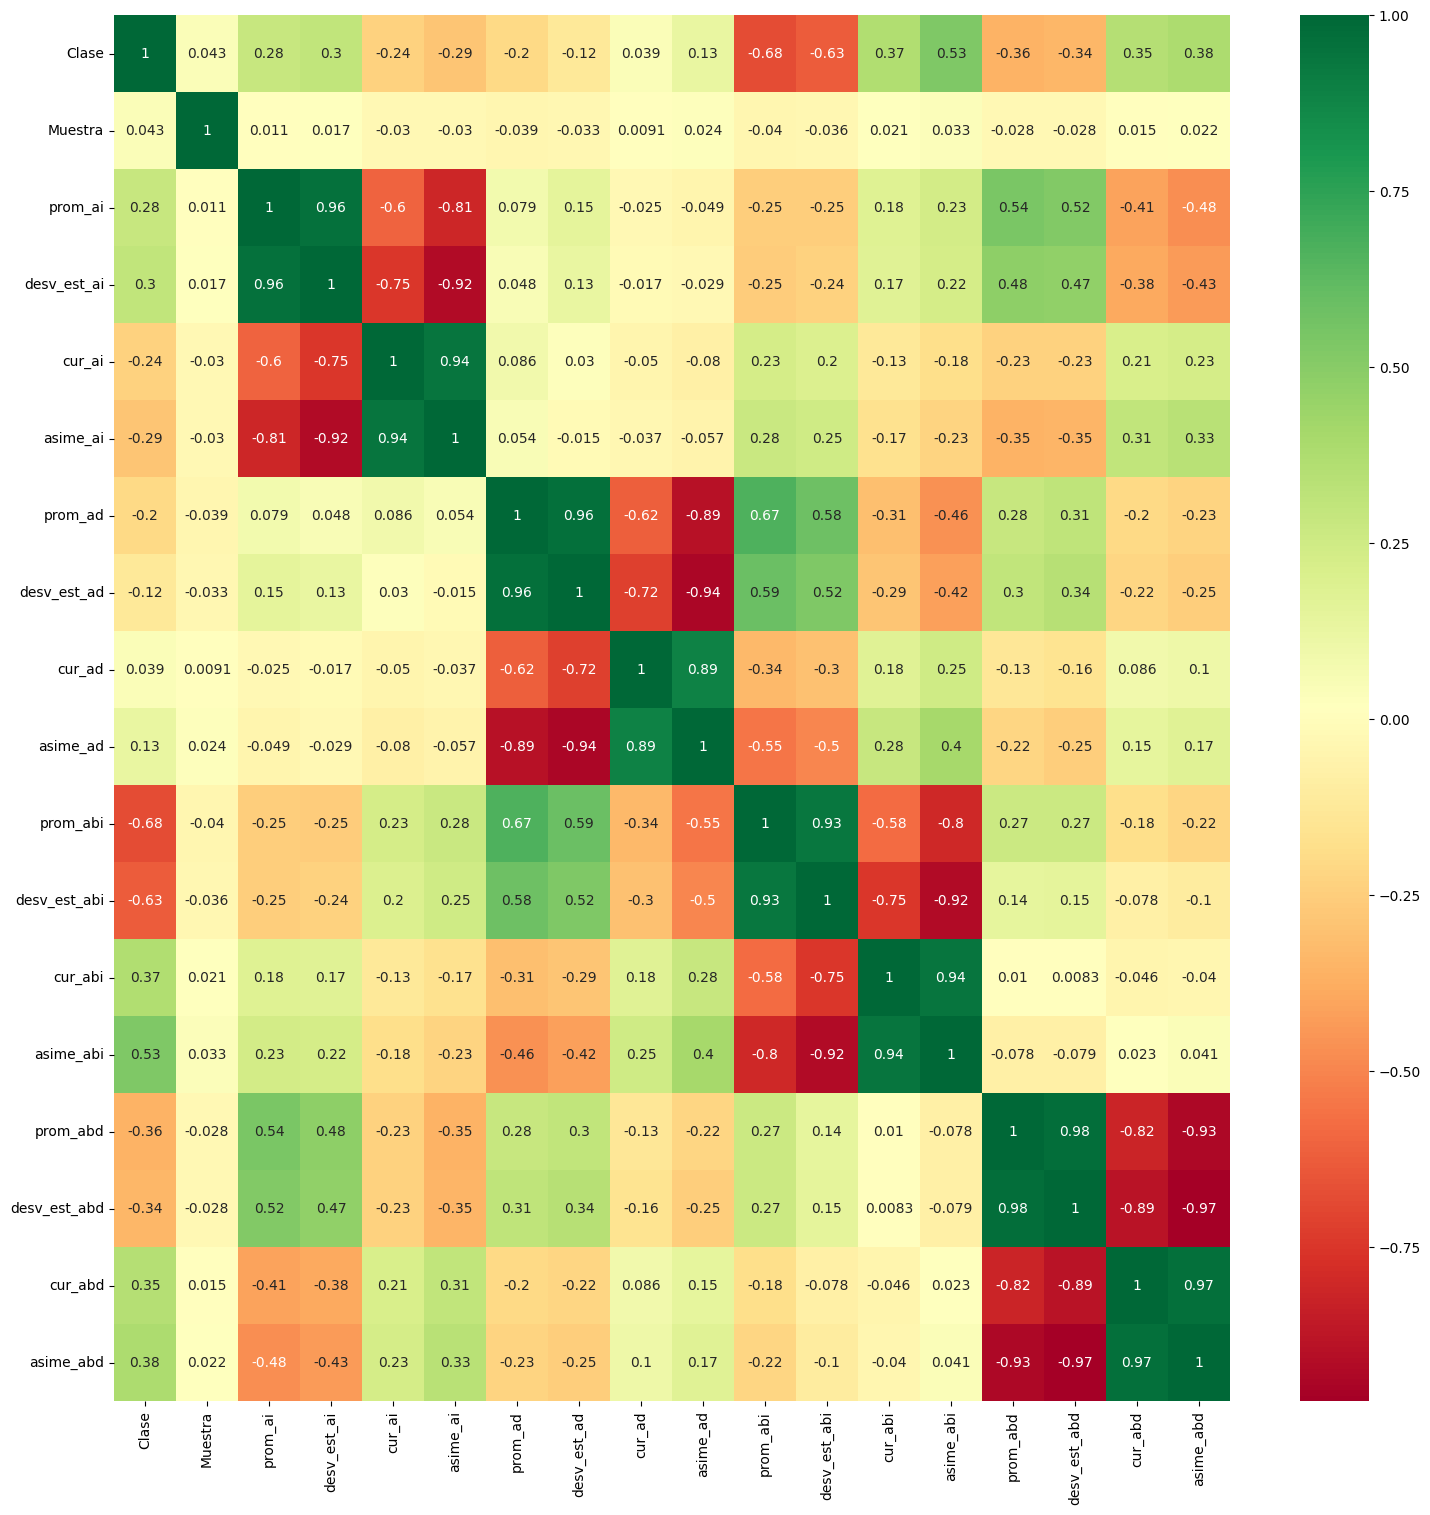

In [ ]:
# Obtener la correlación de cada característica en el dataset
cormat = mnist_filtrado.corr()
top_corr_features = cormat.index
plt.figure(figsize=(18,18))
#Obtener el mapa de calor
g = sns.heatmap(mnist_filtrado[top_corr_features].corr(),annot=True,cmap="RdYlGn")
# Notamos que las caracteristicas con menor correlacion son (asime_ad , desv_est_ad) = -0.92, (asime_ad , desv_est_ad) = -0.94 y (desv_est_abd y asime_abd) = -0.97

In [ ]:
# Creamos el pairplot para ver la posible separabilidad de cada caracteristica con respecto a las demas
fig = sns.pairplot(mnist_filtrado, hue="Clase", palette="Set2", markers=["o", "s"])
display(fig)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Encontramos valores nulos en algunas de las caracteristicas
mnist_filtrado.isnull().sum()

,0
Clase,0
Muestra,0
prom_ai,0
desv_est_ai,0
cur_ai,52
asime_ai,52
prom_ad,0
desv_est_ad,0
cur_ad,6
asime_ad,6


In [ ]:
from sklearn.impute import SimpleImputer

# Vamos a utilizar SimpleImputer con la estrategia "median" para rellenar los valores nulos de cada columna con la mediana de esa misma columna.

imputer = SimpleImputer(strategy="median")
mnist_imputed = pd.DataFrame(imputer.fit_transform(mnist_filtrado), columns=mnist.columns)

In [ ]:
# verificamos que ya no hay valores nulos
mnist_imputed.isnull().sum()

,0
Clase,0
Muestra,0
prom_ai,0
desv_est_ai,0
cur_ai,0
asime_ai,0
prom_ad,0
desv_est_ad,0
cur_ad,0
asime_ad,0


In [ ]:
from sklearn.model_selection import train_test_split

X, y = mnist_imputed.iloc[:, 1:].values, mnist_imputed.iloc[:, 0].values

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25,
                     stratify=y,
                     random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.6,
                    c=cmap(idx),
                    edgecolor='black',
                    marker=markers[idx],
                    label=cl)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)

pca.explained_variance_ratio_

array([3.31434291e-01, 2.97438346e-01, 1.18288308e-01, 9.58915156e-02,
       5.86326837e-02, 3.46756601e-02, 2.82710074e-02, 1.68279401e-02,
       9.40279660e-03, 3.55281011e-03, 1.68867312e-03, 1.22374643e-03,
       7.93428732e-04, 6.39336362e-04, 5.98072307e-04, 5.21442640e-04,
       1.19942252e-04])

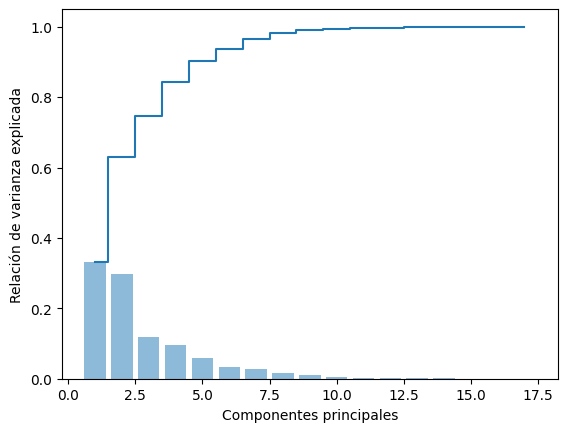

In [ ]:
plt.bar(range(1, 18), pca.explained_variance_ratio_, alpha=0.5, align='center')
plt.step(range(1, 18), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Relación de varianza explicada')
plt.xlabel('Componentes principales')

plt.show()

In [ ]:
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_std)

X_test_pca = pca.transform(X_test_std)

In [ ]:
# Para obtener la matriz de proyección W
w = pca.components_
print(w.T)

[[-0.01634177 -0.01428264 -0.03755755]
 [ 0.17382246 -0.33716549 -0.19775545]
 [ 0.16351376 -0.34544382 -0.24122253]
 [-0.08167772  0.29718127  0.27761934]
 [-0.11669382  0.3454445   0.27397434]
 [ 0.32130621  0.18334179 -0.21458044]
 [ 0.33018874  0.15486384 -0.273248  ]
 [-0.22654154 -0.14327323  0.34052939]
 [-0.3021127  -0.18655021  0.31589247]
 [ 0.26663045  0.27218269  0.13820939]
 [ 0.23116986  0.28377267  0.08878258]
 [-0.14016095 -0.24091351 -0.05949915]
 [-0.19464833 -0.27702712 -0.09348058]
 [ 0.31900962 -0.19526749  0.27493672]
 [ 0.33075806 -0.1928037   0.27849351]
 [-0.2838111   0.19763172 -0.33185161]
 [-0.30636036  0.2060474  -0.33191058]]


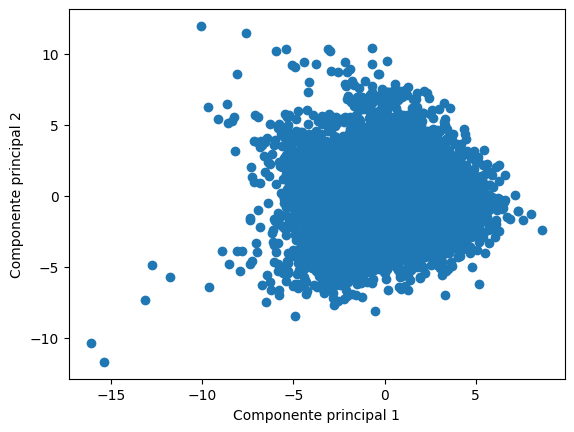

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

In [ ]:
# Grafica en caso de usar 3 componentes con PCA

import plotly.express as px
from sklearn.decomposition import PCA

# Crear DataFrame para Plotly
df_pca = pd.DataFrame(X_train_pca, columns=['Componente 1', 'Componente 2', 'Componente 3'])
df_pca['Clase'] = y_train.astype(str)  # Convertir a cadena para colores categóricos

# Gráfico interactivo
fig = px.scatter_3d(df_pca,
                    x='Componente 1',
                    y='Componente 2',
                    z='Componente 3',
                    color='Clase',
                    symbol='Clase',  # Opcional: diferenciar con símbolos
                    opacity=0.7,
                    title="Componentes principales 3D Interactivo")

# Personalizar
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.update_traces(marker_size=3)
fig.show()

In [ ]:
from sklearn.svm import SVC

# Definir los modelos con diferentes kernels
svm_linear = SVC(kernel='linear', random_state=0)
svm_poly = SVC(kernel='poly', degree=3, random_state=0)  # Grado 3 por defecto
svm_rbf = SVC(kernel='rbf', random_state=0)

# Entrenar los modelos con los datos de entrenamiento
svm_linear.fit(X_train_pca, y_train)
svm_poly.fit(X_train_pca, y_train)
svm_rbf.fit(X_train_pca, y_train)

SVC(random_state=0)

In [ ]:
y_pred_linear = svm_linear.predict(X_test_pca)
y_pred_poly = svm_poly.predict(X_test_pca)
y_pred_rbf = svm_rbf.predict(X_test_pca)

In [ ]:
# Calcula la matriz de confusión
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_poly = confusion_matrix(y_test, y_pred_poly)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print(cm_linear)
print(cm_poly)
print(cm_rbf)

[[1373  117]
 [ 168 1398]]
[[1387  103]
 [ 192 1374]]
[[1389  101]
 [ 176 1390]]


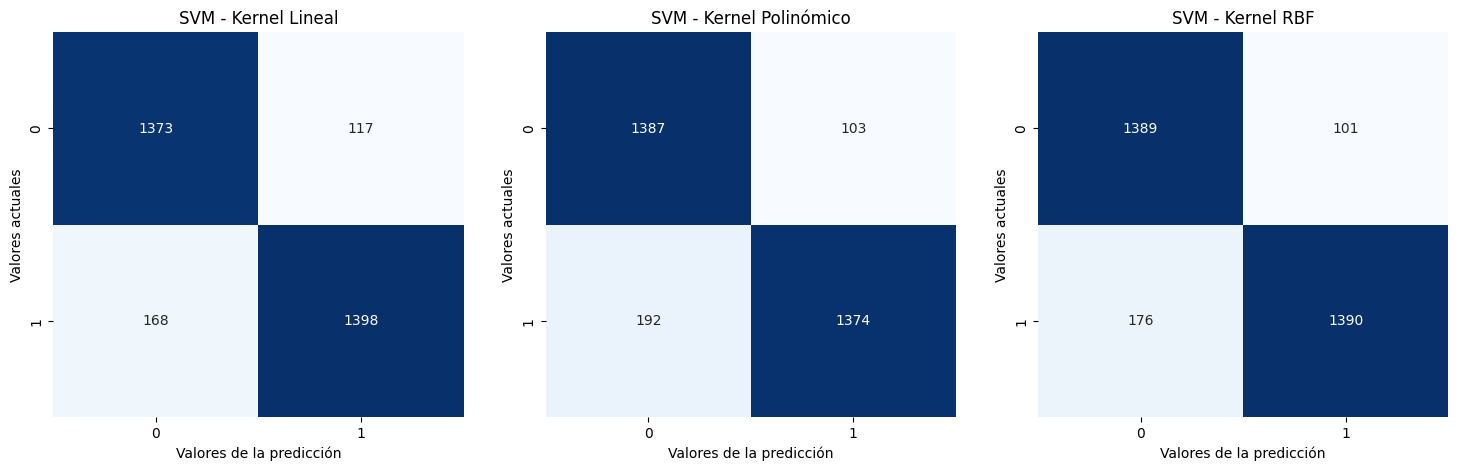

In [ ]:
# Crear una figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definir títulos y matrices para iterar
titles = ['SVM - Kernel Lineal', 'SVM - Kernel Polinómico', 'SVM - Kernel RBF']
cms = [cm_linear, cm_poly, cm_rbf]

# Graficar cada matriz de confusión
for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Valores de la predicción')
    ax.set_ylabel('Valores actuales')

# Mostrar el gráfico
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Función para calcular métricas
def calculate_metrics(cm):
    TP = cm[0, 0]  # Verdaderos Positivos
    FP = cm[0, 1]  # Falsos Positivos
    FN = cm[1, 0]  # Falsos Negativos
    TN = cm[1, 1]  # Verdaderos Negativos

    accuracy = (TP + TN) / np.sum(cm)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    error_rate = 1 - accuracy

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall (Sensibilidad)": recall,
        "Specificity (Especificidad)": specificity,
        "Error Rate": error_rate,
    }

# Calcular métricas para cada modelo
metrics_linear = calculate_metrics(cm_linear)
metrics_poly = calculate_metrics(cm_poly)
metrics_rbf = calculate_metrics(cm_rbf)

# Imprimir resultados en porcentaje
print("Métricas para el modelo Linear:")
for key, value in metrics_linear.items():
    print(f"{key}: {value * 100:.2f}%")

print("\nMétricas para el modelo Poly:")
for key, value in metrics_poly.items():
    print(f"{key}: {value * 100:.2f}%")

print("\nMétricas para el modelo RBF:")
for key, value in metrics_rbf.items():
    print(f"{key}: {value * 100:.2f}%")

Métricas para el modelo Linear:
Accuracy: 90.67%
Precision: 92.15%
Recall (Sensibilidad): 89.10%
Specificity (Especificidad): 92.28%
Error Rate: 9.33%

Métricas para el modelo Poly:
Accuracy: 90.35%
Precision: 93.09%
Recall (Sensibilidad): 87.84%
Specificity (Especificidad): 93.03%
Error Rate: 9.65%

Métricas para el modelo RBF:
Accuracy: 90.94%
Precision: 93.22%
Recall (Sensibilidad): 88.75%
Specificity (Especificidad): 93.23%
Error Rate: 9.06%
